# Phase 4 — SHAP Explainability
## Credit Risk Scoring Model

A model that just says "this person will default" is not useful to a bank. The loan officer needs to know *why*.  
SHAP (SHapley Additive exPlanations) gives us exactly that.

**What SHAP does:**
- Assigns each feature a contribution score for every single prediction
- Positive SHAP value → feature pushed the prediction toward Bad Credit
- Negative SHAP value → feature pushed toward Good Credit
- The sum of all SHAP values = the model's final output (log-odds)

**Where SHAP comes from:**
SHAP values are rooted in game theory (Shapley values). The idea: imagine each feature is a "player" contributing to the final prediction. SHAP fairly distributes the credit/blame among all players based on their marginal contributions.

**Why SHAP over feature importance from the model itself?**  
Random Forest's built-in importance is biased toward high-cardinality features and doesn't tell you *direction* (does high credit amount increase or decrease risk?). SHAP gives direction, magnitude, and works consistently across any model.

## Step 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
import pickle
import json
import warnings

warnings.filterwarnings('ignore')
plt.rcParams["figure.figsize"] = (12, 6)

# SHAP needs matplotlib backend
shap.initjs()

print("Imports successful.")

Imports successful.


## Step 2 — Load Model and Data

In [2]:
with open('../data/processed/rf_model.pkl', 'rb') as f:
    rf = pickle.load(f)

with open('../data/processed/model_meta.json') as f:
    meta = json.load(f)

X_test  = pd.read_csv('../data/processed/X_test.csv')
X_train = pd.read_csv('../data/processed/X_train.csv')
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"Model     : {meta['best_model']}")
print(f"ROC-AUC   : {meta['rf_auc']:.4f}")
print(f"Threshold : {meta['rf_threshold']}")
print(f"Features  : {X_test.shape[1]}")
print(f"Test rows : {X_test.shape[0]}")

Model     : Random Forest
ROC-AUC   : 0.8035
Threshold : 0.22
Features  : 41
Test rows : 200


## Step 3 — Compute SHAP Values

We use `TreeExplainer` — a fast SHAP explainer built specifically for tree-based models (Random Forest, XGBoost, etc.).

**Why TreeExplainer and not the generic Explainer?**  
The generic SHAP explainer uses random permutations to estimate contributions — slow for large feature sets.  
TreeExplainer uses the tree structure directly to compute exact SHAP values in polynomial time. Much faster and exact.

`shap_values` is a 3D array:
- Axis 0 → rows (applicants)
- Axis 1 → features
- Axis 2 → classes (index 1 = Bad Credit class)

We use `shap_values[:, :, 1]` — SHAP values for predicting Bad Credit.

In [3]:
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# For binary classification, index 1 = Bad Credit class
sv = shap_values[:, :, 1]

print(f"SHAP values computed.")
print(f"Shape: {sv.shape}  →  {sv.shape[0]} applicants × {sv.shape[1]} features")

SHAP values computed.
Shape: (200, 41)  →  200 applicants × 41 features


## Step 4 — Global Feature Importance (Bar Plot)

**Mean absolute SHAP value per feature** = how much, on average, that feature moves the model's prediction across all applicants.

This answers: **"What does the model care about most?"**

Unlike Random Forest's built-in importance which only tells you *how often* a feature was used, SHAP importance tells you *how much impact* it had — a much more honest measure.

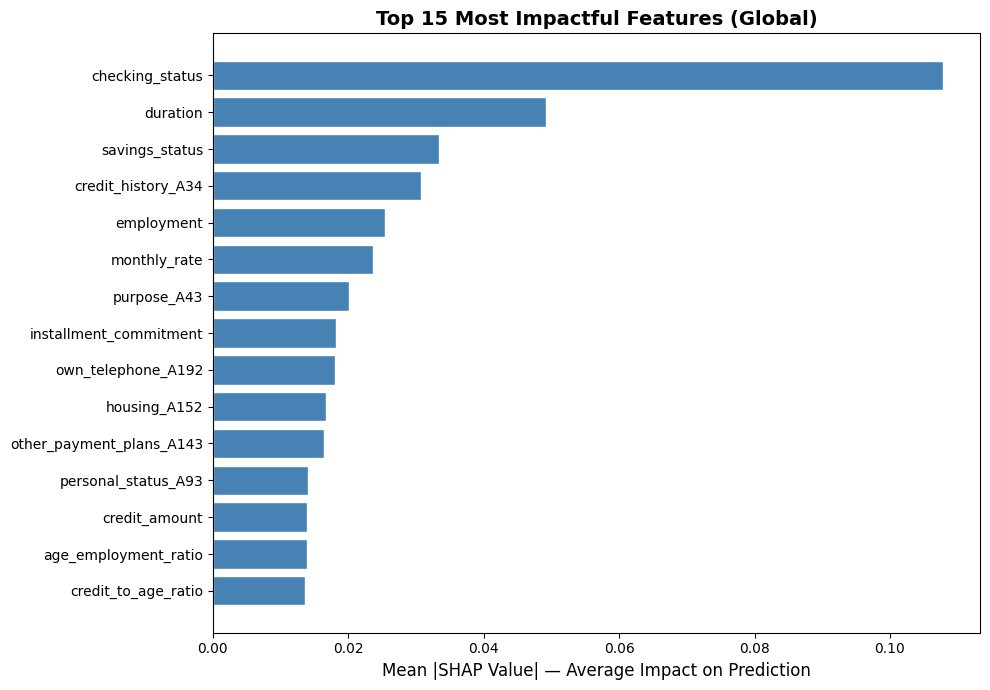


Top 10 features by SHAP importance:
checking_status           0.107899
duration                  0.049130
savings_status            0.033469
credit_history_A34        0.030756
employment                0.025378
monthly_rate              0.023602
purpose_A43               0.020093
installment_commitment    0.018245
own_telephone_A192        0.017994
housing_A152              0.016675


In [4]:
mean_abs_shap = pd.Series(
    np.abs(sv).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

top15 = mean_abs_shap.head(15)

plt.figure(figsize=(10, 7))
bars = plt.barh(top15.index[::-1], top15.values[::-1], color='steelblue', edgecolor='white')
plt.xlabel('Mean |SHAP Value| — Average Impact on Prediction', fontsize=12)
plt.title('Top 15 Most Impactful Features (Global)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features by SHAP importance:")
print(mean_abs_shap.head(10).to_string())

## Step 5 — SHAP Beeswarm Plot (Summary Plot)

The beeswarm plot is the most information-dense SHAP visualization. It shows:

- **Y-axis** → features ranked by importance (top = most impactful)
- **X-axis** → SHAP value (positive = pushes toward Bad Credit, negative = toward Good)
- **Color** → actual feature value (red = high, blue = low)
- **Each dot** → one applicant

**How to read it:**
- Red dots on the right → high feature value increases default risk
- Blue dots on the right → low feature value increases default risk
- Spread out dots → feature has highly variable impact across applicants

This is what separates an explainable model from a black box.

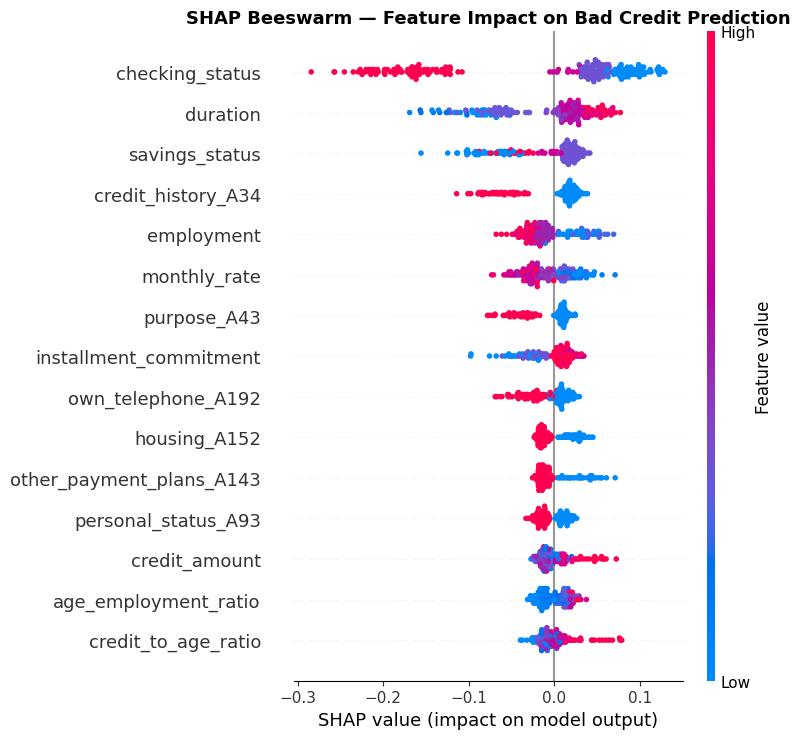

In [5]:
plt.figure()
shap.summary_plot(
    sv,
    X_test,
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm — Feature Impact on Bad Credit Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — SHAP Dependence Plot

A dependence plot shows **how one specific feature's value affects its SHAP contribution**.

We pick `checking_status` and `credit_amount` — two features the model cares most about.

**How to read it:**
- X-axis → actual feature value
- Y-axis → SHAP value for that feature (positive = pushes toward Bad Credit)
- Color → a second feature automatically chosen by SHAP that interacts with this one

This is incredibly powerful for business storytelling: "applicants with checking balance < 0 DM have 3x higher SHAP contribution to default risk."

Plotting dependence for: ['checking_status', 'duration']


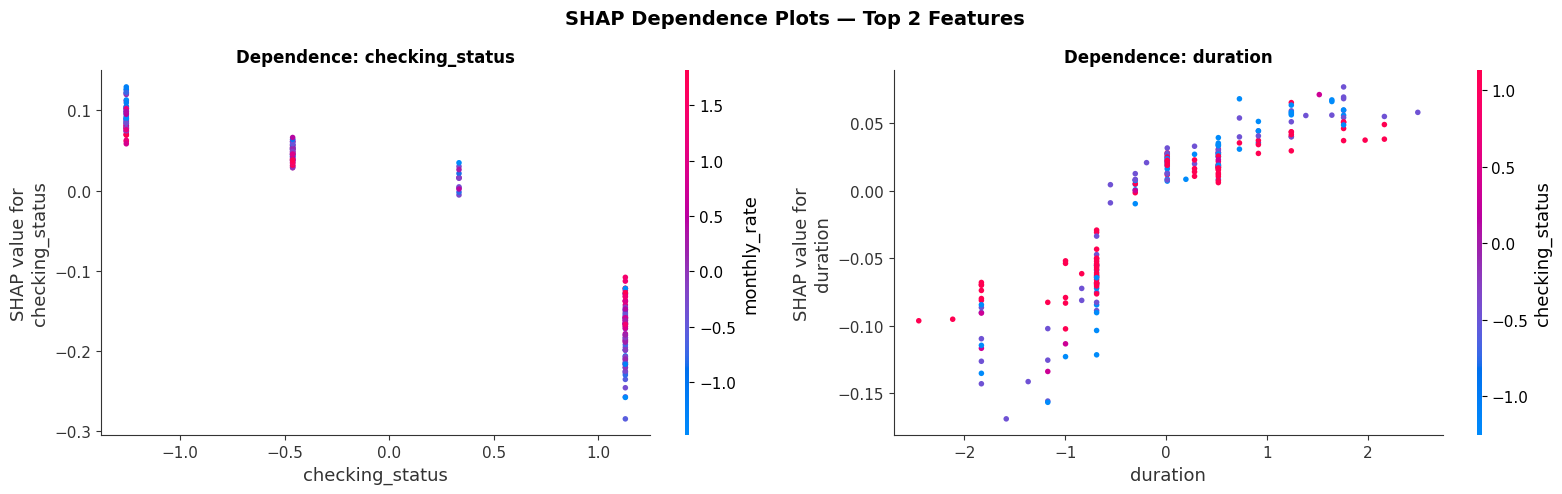

In [6]:
top2_features = mean_abs_shap.head(2).index.tolist()
print(f"Plotting dependence for: {top2_features}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, feat in zip(axes, top2_features):
    shap.dependence_plot(
        feat, sv, X_test,
        ax=ax, show=False
    )
    ax.set_title(f'Dependence: {feat}', fontsize=12, fontweight='bold')

plt.suptitle('SHAP Dependence Plots — Top 2 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Individual Prediction Explanation (Waterfall Plot)

This is the most powerful output for a real-world credit scoring system.

For a **single applicant**, the waterfall plot shows:
- The model's baseline prediction (average output across all applicants)
- Each feature's contribution — how much it pushed the score up or down
- The final predicted probability of default

**Business use:** A loan officer can show this to an applicant:  
*"Your application was flagged because of your checking account balance and short loan duration. If you had a savings account, your risk score would drop by X."*

In [7]:
# Pick one high-risk and one low-risk applicant from the test set
rf_probs = rf.predict_proba(X_test)[:, 1]

high_risk_idx = np.argmax(rf_probs)
low_risk_idx  = np.argmin(rf_probs)

print(f"High-risk applicant  → index {high_risk_idx}, P(default) = {rf_probs[high_risk_idx]:.3f}, Actual = {'Bad' if y_test.iloc[high_risk_idx]==1 else 'Good'}")
print(f"Low-risk  applicant  → index {low_risk_idx},  P(default) = {rf_probs[low_risk_idx]:.3f},  Actual = {'Bad' if y_test.iloc[low_risk_idx]==1 else 'Good'}")

High-risk applicant  → index 195, P(default) = 0.878, Actual = Bad
Low-risk  applicant  → index 12,  P(default) = 0.024,  Actual = Good


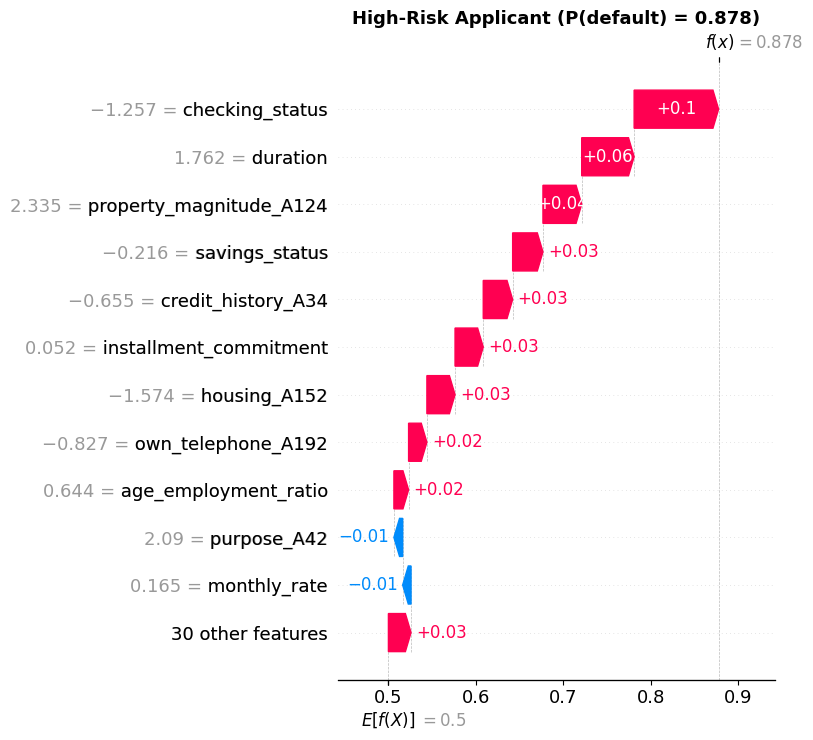

In [8]:
# Build SHAP Explanation objects for waterfall plots
explanation = shap.Explanation(
    values          = sv,
    base_values     = explainer.expected_value[1],
    data            = X_test.values,
    feature_names   = X_test.columns.tolist()
)

# High-risk applicant
plt.figure()
shap.plots.waterfall(explanation[high_risk_idx], max_display=12, show=False)
plt.title(f'High-Risk Applicant (P(default) = {rf_probs[high_risk_idx]:.3f})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_waterfall_highrisk.png', dpi=150, bbox_inches='tight')
plt.show()

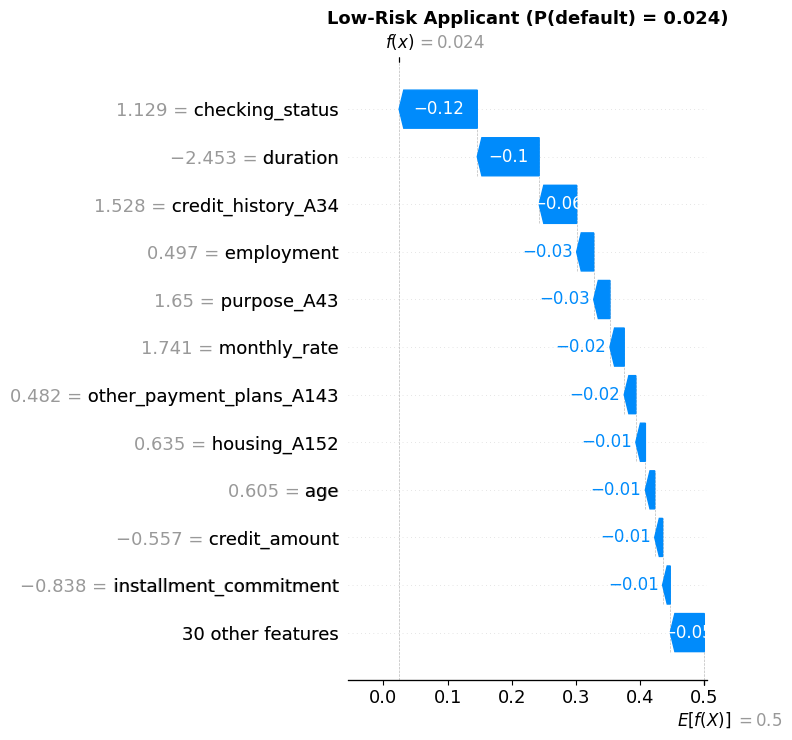

In [9]:
# Low-risk applicant
plt.figure()
shap.plots.waterfall(explanation[low_risk_idx], max_display=12, show=False)
plt.title(f'Low-Risk Applicant (P(default) = {rf_probs[low_risk_idx]:.3f})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_waterfall_lowrisk.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 — Business Insights Summary

Extract concrete, quantified business insights from SHAP — the kind that go on a resume bullet or in a report.

In [10]:
shap_df = pd.DataFrame(sv, columns=X_test.columns)

print("=" * 60)
print("  SHAP-BASED BUSINESS INSIGHTS")
print("=" * 60)

# Insight 1: Top risk drivers
top5 = mean_abs_shap.head(5)
print("\n1. TOP 5 RISK DRIVERS (by average SHAP impact):")
for feat, val in top5.items():
    print(f"   {feat:<35} impact = {val:.4f}")

# Insight 2: Direction of top features
print("\n2. FEATURE DIRECTION (does higher value = more risk?):")
for feat in top5.index:
    corr = np.corrcoef(X_test[feat], shap_df[feat])[0, 1]
    direction = "Higher value → MORE risk" if corr > 0 else "Higher value → LESS risk"
    print(f"   {feat:<35} {direction}  (r={corr:.2f})")

# Insight 3: Average risk contribution by checking_status group
print("\n3. AVERAGE SHAP CONTRIBUTION by checking_status:")
for val in sorted(X_test['checking_status'].unique()):
    mask = X_test['checking_status'] == val
    avg_shap = shap_df.loc[mask, 'checking_status'].mean()
    label = {0: "Unknown/None", 1: "< 0 DM (in debt)", 2: "0–200 DM", 3: ">= 200 DM"}.get(int(val), str(val))
    print(f"   {label:<30}  avg SHAP = {avg_shap:+.4f}")

# Insight 4: High vs low risk profile comparison
print("\n4. AVERAGE SHAP VALUES — High Risk vs Low Risk applicants:")
threshold = meta['rf_threshold']
high_risk_mask = rf_probs >= threshold
low_risk_mask  = rf_probs < threshold

comparison = pd.DataFrame({
    'High Risk Avg SHAP': shap_df[high_risk_mask].mean(),
    'Low Risk Avg SHAP' : shap_df[low_risk_mask].mean(),
}).loc[mean_abs_shap.head(8).index]
comparison['Difference'] = comparison['High Risk Avg SHAP'] - comparison['Low Risk Avg SHAP']
print(comparison.to_string(float_format='{:+.4f}'.format))

  SHAP-BASED BUSINESS INSIGHTS

1. TOP 5 RISK DRIVERS (by average SHAP impact):
   checking_status                     impact = 0.1079
   duration                            impact = 0.0491
   savings_status                      impact = 0.0335
   credit_history_A34                  impact = 0.0308
   employment                          impact = 0.0254

2. FEATURE DIRECTION (does higher value = more risk?):
   checking_status                     Higher value → LESS risk  (r=-0.95)
   duration                            Higher value → MORE risk  (r=0.89)
   savings_status                      Higher value → MORE risk  (r=0.09)
   credit_history_A34                  Higher value → LESS risk  (r=-0.96)
   employment                          Higher value → LESS risk  (r=-0.82)

3. AVERAGE SHAP CONTRIBUTION by checking_status:
   -1.2565431808298464             avg SHAP = +0.0921
   Unknown/None                    avg SHAP = +0.0470
   Unknown/None                    avg SHAP = +0.0136
   <

## Step 9 — Save SHAP Values & Explainer

We save the SHAP values and explainer so the Streamlit app can generate individual explanations for new applicants in real time.

In [11]:
with open('../data/processed/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

shap_df.to_csv('../data/processed/shap_values_test.csv', index=False)

print("Saved:")
print("  data/processed/shap_explainer.pkl")
print("  data/processed/shap_values_test.csv")
print("\nPhase 4 — SHAP Explainability complete.")
print("Ready for Phase 5 — Business Insights Notebook.")

Saved:
  data/processed/shap_explainer.pkl
  data/processed/shap_values_test.csv

Phase 4 — SHAP Explainability complete.
Ready for Phase 5 — Business Insights Notebook.
